# ドイチュ-ジョサのアルゴリズム（Deutsch-Jozsa algorithm）
ドイチュ-ジョサのアルゴリズムは、ドイチュのアルゴリズムを複数ビットに拡張したものです。  
$n$ bitの入力（0 or 1）に対して0か1を返す関数$f$に対して、constantかbalancedかを判定することのできるアルゴリズムです。constantな関数とは$2^n$通りの入力に対してすべて0を返すかすべて1を返す関数であり、balancedな関数とは$2^n$通りの入力のうち$2^{n-1}$通りの入力で0、それ以外で1を返す関数のことです。ドイチュ-ジョサの関数ではconstantでもbalancedでもない関数は扱わないこととします。
<div style="display: flex; gap: 50px;">

<div>
  <strong>constantな関数の例</strong>
  
  | $a$ | $f_1(a)$ |
  | :---: | :---: |
  | $00$ | $0$ |
  | $01$ | $0$ |
  | $10$ | $0$ |
  | $11$ | $0$ |
</div>

<div>
  <strong>balancedな関数の例</strong>

  | $a$ | $f_2(a)$ |
  | :---: | :---: |
  | $00$ | $0$ |
  | $01$ | $1$ |
  | $10$ | $1$ |
  | $11$ | $0$ |
</div>

</div>

In [30]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

まず、ドイチュ-ジョサのアルゴリズムにおいて判定対象となる関数$f$を生成する。このような内部の状況はよくわからないが、入力に対して決まった出力を行うものをオラクルと呼びます。  
関数$f$の生成の際には必ずconstantかbalancedになるようにしなければいけないことに注意します。

In [31]:
def dj_query(num_qubits):
    qc = QuantumCircuit(num_qubits + 1)

    #constant関数の生成---
    if np.random.randint(0,2): #50%,50%の確率で0か1を返す。1=Trueを意味する
        qc.x(num_qubits) #最後のbit（ancilla bit）にだけxゲートをかけて出力が常に1の定数関数
    if np.random.randint(0,2):
        return qc #何もしないことを意味し、これは出力が常に0の定数関数
    #---

    #balanced関数の生成---
    on_states = np.random.choice( #0から2^num_qubits-1までの整数の中から2^(num_quibits-1)個、すなわち半分個をランダムに抽出
        range(2 ** num_qubits),
        2**num_qubits // 2, #2で割った商の整数部分
        replace = False,
    )

    def add_cx(qc, bit_string): #ヘルパー関数
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc
    
    for state in on_states:
        qc.barrier()
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits) #mcxはMulti-controlled Xゲートで、controllビットがすべて1のときにtargetビットを反転
        qc = add_cx(qc, f"{state:0b}")
    
    qc.barrier()

    return qc
    #---

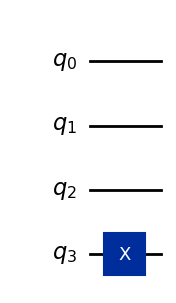

In [32]:
display(dj_query(3).draw(output="mpl"))

dj_queryで生成される量子回路は
* **constant関数**  
何もゲートがない回路（0）と補助ビットにのみxゲートがある回路（1）
* **balanced関数**  
$2^n$通りの入力に対して$2^{n-1}$個のセクターに分かれて対応する入力の時のみMulti-controlled NOTゲートをかける回路

次に、Deutsch-Jozsa algorithmを動かすための回路を作る関数を定義します。

In [33]:
def compile_circuit(function: QuantumCircuit):

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n) #n+1個のqubitとn個の古典ビットを持つ量子回路を作成
    qc.x(n) #ancilla bitのみを|1>に初期化する
    qc.h(range(n + 1)) #すべてのqubitにHadamardゲートをかける
    qc.compose(function, inplace =True)
    qc.h(range(n)) #ancilla bit以外のqubitにHadamardゲートをかける
    qc.measure(range(n), range(n))
    return qc

最後にDeutsch-Jozsa algorithmを実際に動かしてシミュレーションしてみます。

In [34]:
def dj_algorithm(function: QuantumCircuit):

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots = 1, memory = True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]: #measurements[0]に少なくとも1つの"1"が含まれていればbalanced（すべてが0となるような状態の確率振幅が0だから）
        return "balanced"
    return "constant"

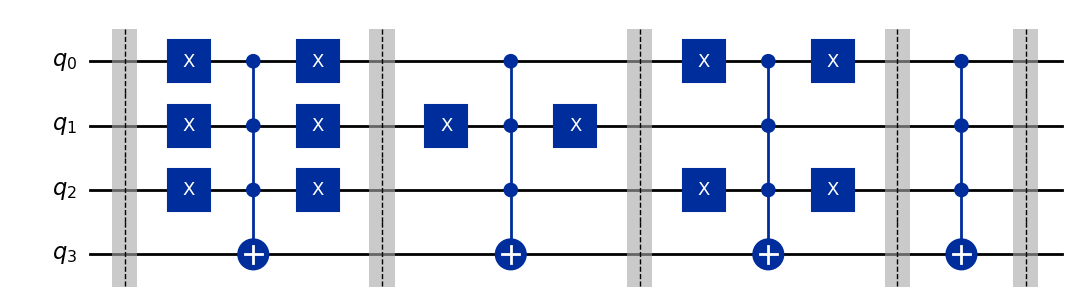

'balanced'

In [35]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))